# Практична робота №2.
# Побудова та оцiнювання якостi моделей класифiкацiї та регресiї засобами бiблiотеки Scikit-Learn Python
Варіант 25 \
Виконали студенти групи КА-35 Бернацький Артем, Бубало Анна, Іванкевич Богдан, Шальман Тимофій

## Dataset a

In [1]:
from sklearn.datasets import make_blobs
import numpy as np


X, y_true = make_blobs (
    n_samples =400,
    centers =4,
    cluster_std =0.60,
    random_state=0
)

rng = np.random.RandomState(13)
X_stretched = np.dot(X, rng.randn(2, 2))

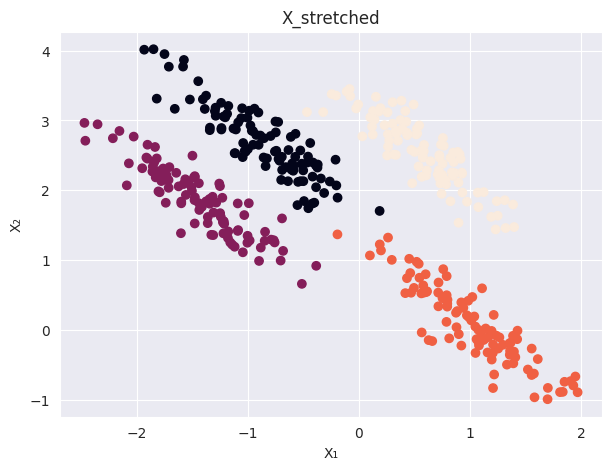

In [2]:
import matplotlib.pyplot as plt


def show_scatter(X, y, title=None):
    plt.figure(figsize=(7, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y)
    if title:
        plt.title(title)
    plt.xlabel("X₁")
    plt.ylabel("X₂")
    plt.show()

show_scatter(X_stretched, y_true, title="X_stretched")

In [3]:
import warnings

from matplotlib.colors import ListedColormap
import seaborn as sns

import sklearn.metrics as metrics

from sklearn.preprocessing import label_binarize


def plot_decision_regions(X, y, model, model_name="model", resolution=0.02):
    # Створюємо сітку точок для візуалізації меж
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Створюємо сітку координат
    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, resolution),
        np.arange(x2_min, x2_max, resolution)
    )

    # Прогноз для кожної точки сітки
    pred = model.predict(np.c_[xx1.ravel(), xx2.ravel()])
    pred = pred.reshape(xx1.shape)

    # Малюємо графік
    markers = ('o','s','^','v','<')
    colors = ('red','blue','lightgreen','gray','cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    plt.figure(figsize=(8, 6))
    plt.contourf(xx1, xx2, pred, alpha=0.3, cmap=cmap)
    plt.title(model_name)
    plt.xlabel("X₁")
    plt.ylabel("X₂")

    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(
            x=X[y == cl,0],
            y=X[y == cl,1],
            alpha=0.8,
            c=colors[idx],
            marker=markers[idx],
            label=f"Class {cl}",
            edgecolor="black"
        )

    plt.show()


def get_model_score(y_true, y_pred):
    warnings.filterwarnings("ignore")

    class_names = [f"Class {i}" for i in np.unique(y_true).astype(int)]
    # Classification report
    print(metrics.classification_report(y_test, y_pred, target_names=class_names))

    # Confusion matrix
    conf_matrix = metrics.confusion_matrix(y_test, y_pred)
    plt.figure(figsize =(6, 6))
    sns.heatmap(
        data=conf_matrix,
        xticklabels=class_names,
        yticklabels=class_names,
        annot=True,
        fmt="d",
        square=True,
        cmap="coolwarm",
        vmax=20
    )
    plt.ylabel("True class")
    plt.xlabel("Predicted class")
    plt.show()

    warnings.filterwarnings("always")


def plot_roc_auc(model, X_test, y_true, classes=None):
    """
    Побудова ROC–AUC кривої для бінарної або мультикласової класифікації.
    Параметри:
        model   - навчена модель
        X_test  - тестові ознаки
        y_true  - справжні мітки
        classes - список усіх класів (якщо None - визначиться автоматично)
    """

    # Отримуємо ймовірності або передбачення
    y_score = model.predict_proba(X_test)

    if classes is None:
        classes = np.unique(y_true)
    n_classes = len(classes)

    # Якщо бінарна класифікація
    if n_classes == 2:
        if y_score.ndim > 1:
            y_score = y_score[:, 1]
        fpr, tpr, _ = metrics.roc_curve(y_true, y_score)
        roc_auc = metrics.auc(fpr, tpr)

        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
        plt.plot([0, 1], [0, 1], "k:", alpha=0.5)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC-curve (binary classification)")
        plt.legend()
        plt.show()
        print(f"ROC–AUC = {roc_auc:.3f}")

    # Якщо мультикласова класифікація
    else:
        y_true_bin = label_binarize(y_true, classes=classes)
        if y_score.ndim == 1 or y_score.shape[1] == 1:
            y_score = label_binarize(y_score, classes=classes)

        fpr, tpr, roc_auc = {}, {}, {}
        for i in range(n_classes):
            if np.sum(y_true_bin[:, i]) == 0:
                continue  # пропускаємо класи без позитивних прикладів
            fpr[i], tpr[i], _ = metrics.roc_curve(y_true_bin[:, i], y_score[:, i])
            roc_auc[i] = metrics.auc(fpr[i], tpr[i])

        # Усереднений (macro) ROC–AUC
        all_fpr = np.unique(np.concatenate([fpr[i] for i in fpr]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in fpr:
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= len(fpr)
        macro_auc = metrics.auc(all_fpr, mean_tpr)

        plt.figure()
        for i in fpr:
            plt.plot(fpr[i], tpr[i], label=f"Class {classes[i]} (AUC = {roc_auc[i]:.3f})")
        plt.plot(all_fpr, mean_tpr, "k--", label=f"Macro-average (AUC = {macro_auc:.3f})", alpha=0.8)
        plt.plot([0, 1], [0, 1], "k:", alpha=0.5)
        plt.xlabel("False Positive Rate")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC-curve (multiclass classification)")
        plt.legend()
        plt.show()

        print(f"Macro-average ROC-AUC = {macro_auc:.3f}")


def plot_pr_curve(model, X_test, y_true, classes=None):
    """
    Побудова Precision-Recall кривої для бінарної або мультикласової класифікації.
    Параметри:
        model   - навчена модель
        X_test  - тестові ознаки
        y_true  - справжні мітки
        classes - список усіх класів (якщо None - визначиться автоматично)
    """

    y_score = model.predict_proba(X_test)

    if classes is None:
        classes = np.unique(y_true)
    n_classes = len(classes)

    # Бінарна класифікація
    if n_classes == 2:
        if y_score.ndim > 1:
            y_score = y_score[:, 1]
        precision, recall, _ = metrics.precision_recall_curve(y_true, y_score)
        ap = metrics.average_precision_score(y_true, y_score)

        plt.figure()
        plt.plot(recall, precision, label=f"AP = {ap:.3f}")
        plt.plot([1, 0], [0, 1], "k:", alpha=0.5)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision–Recall ()")
        plt.legend()
        plt.show()
        print(f"Average Precision (AUC PR) = {ap:.3f}")

    # Мультикласова класифікація
    else:
        y_true_bin = label_binarize(y_true, classes=classes)
        if y_score.ndim == 1 or y_score.shape[1] == 1:
            y_score = label_binarize(y_score, classes=classes)

        precision, recall, ap = {}, {}, {}
        for i in range(n_classes):
            if np.sum(y_true_bin[:, i]) == 0:
                continue  # пропускаємо класи без позитивних прикладів
            precision[i], recall[i], _ = metrics.precision_recall_curve(y_true_bin[:, i], y_score[:, i])
            ap[i] = metrics.average_precision_score(y_true_bin[:, i], y_score[:, i])

        # Усереднення
        all_recall = np.unique(np.concatenate([recall[i] for i in recall]))
        mean_precision = np.zeros_like(all_recall)
        for i in recall:
            mean_precision += np.interp(all_recall, recall[i][::-1], precision[i][::-1])
        mean_precision /= len(recall)
        macro_ap = np.mean(list(ap.values()))

        plt.figure()
        for i in precision:
            plt.plot(recall[i], precision[i], label=f"Class {classes[i]} (AP = {ap[i]:.3f})")
        plt.plot(all_recall, mean_precision, "k--", label=f"Macro-average (AP = {macro_ap:.3f})", alpha=0.8)
        plt.plot([1, 0], [0, 1], "k:", alpha=0.5)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision–Recall curve")
        plt.legend()
        plt.show()

        print(f"Macro-average AUC Precision–Recall = {macro_ap:.3f}")

In [4]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_stretched, y_true, test_size=0.25, random_state=42
)

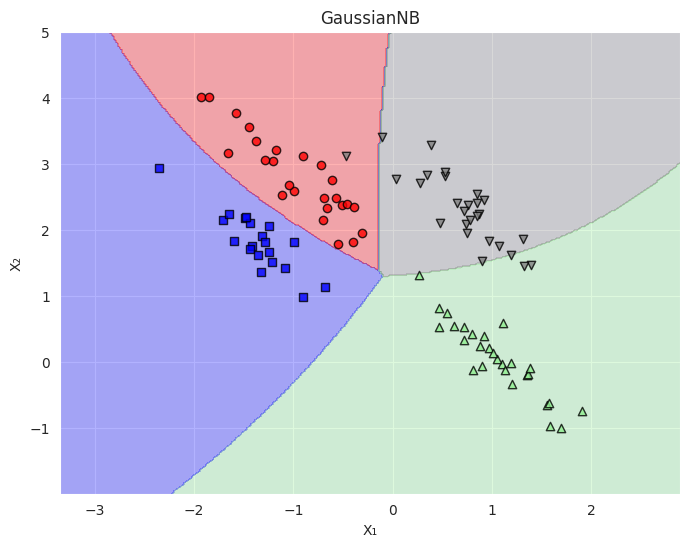

In [5]:
from sklearn.naive_bayes import GaussianNB


GNB_clf = GaussianNB()
GNB_clf.fit(X_train, y_train)

plot_decision_regions(X_test, y_test, GNB_clf, model_name="GaussianNB")

              precision    recall  f1-score   support

     Class 0       0.96      1.00      0.98        25
     Class 1       1.00      1.00      1.00        20
     Class 2       0.90      1.00      0.95        28
     Class 3       1.00      0.85      0.92        27

    accuracy                           0.96       100
   macro avg       0.97      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



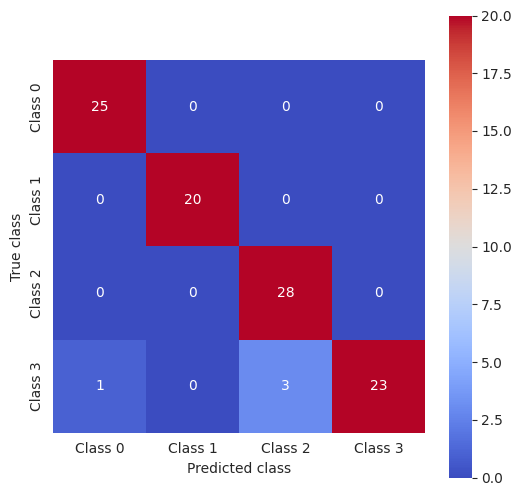

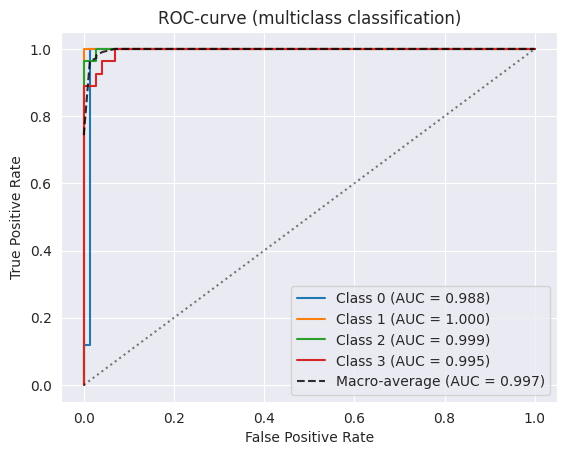

Macro-average ROC-AUC = 0.997


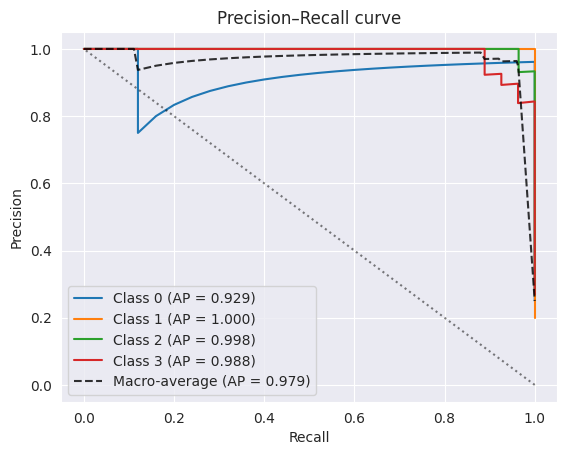

Macro-average AUC Precision–Recall = 0.979


In [6]:
pred = GNB_clf.predict(X_test)
get_model_score(y_test, pred)
plot_roc_auc(GNB_clf, X_test, y_test)
plot_pr_curve(GNB_clf, X_test, y_test)

In [7]:
from sklearn.model_selection import cross_val_score


# Overfitting
train_score = cross_val_score(GNB_clf, X_train, y_train, cv=5)
test_score = cross_val_score(GNB_clf, X_test, y_test, cv=5)
print(np.mean(train_score) - np.mean(test_score))

0.029999999999999916


In [8]:
GNB_clf.predict_proba(X_test)

array([[4.11721115e-04, 1.64464544e-06, 2.45984916e-04, 9.99340649e-01],
       [2.78154771e-03, 4.36220226e-06, 4.35719745e-06, 9.97209733e-01],
       [9.71928565e-01, 2.46272369e-02, 2.15304551e-09, 3.44419558e-03],
       [8.95396155e-01, 7.73997110e-02, 1.37999768e-06, 2.72027541e-02],
       [1.11086895e-09, 6.39184912e-09, 9.99994122e-01, 5.87055539e-06],
       [8.84629242e-01, 1.15370754e-01, 1.64590140e-16, 4.78805886e-09],
       [6.82288809e-09, 4.17449322e-08, 9.99986191e-01, 1.37604781e-05],
       [1.17910603e-09, 2.10414480e-09, 9.99970507e-01, 2.94897865e-05],
       [8.29957275e-01, 1.69849513e-01, 3.39179438e-09, 1.93208501e-04],
       [1.80132455e-01, 8.19867311e-01, 4.31749350e-10, 2.33657245e-07],
       [1.37212513e-01, 8.62786382e-01, 1.33700278e-08, 1.09109028e-06],
       [1.14066333e-04, 2.69889535e-07, 2.35486593e-04, 9.99650177e-01],
       [7.09421610e-01, 1.42692600e-01, 2.58423452e-04, 1.47627367e-01],
       [7.59278676e-15, 3.12484491e-13, 9.99999999e

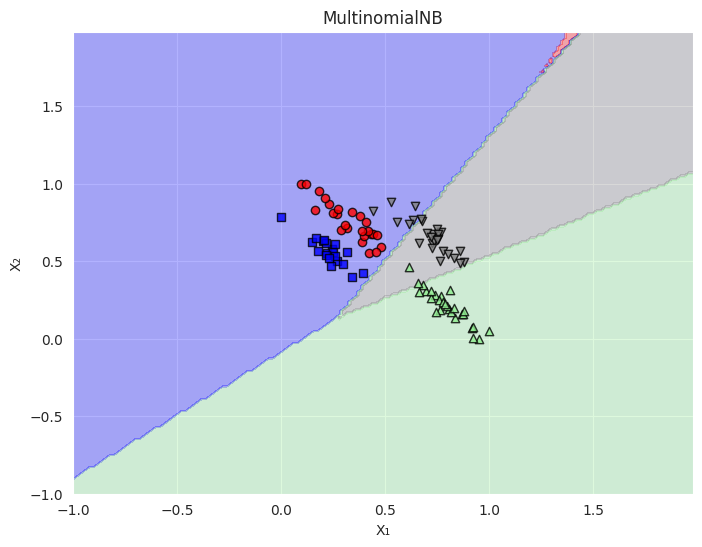

In [9]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler


# Використовуємо MinMaxScaler, оскільки MultinomialNB очікує невід'ємні значення
scaler = MinMaxScaler()

X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test = scaler.fit_transform(X_test)

MNB_clf = MultinomialNB()
MNB_clf.fit(X_scaled_train, y_train)

plot_decision_regions(X_scaled_test, y_test, MNB_clf, model_name="MultinomialNB")

              precision    recall  f1-score   support

     Class 0       0.00      0.00      0.00        25
     Class 1       0.39      1.00      0.56        20
     Class 2       1.00      0.93      0.96        28
     Class 3       0.91      0.78      0.84        27

    accuracy                           0.67       100
   macro avg       0.58      0.68      0.59       100
weighted avg       0.60      0.67      0.61       100



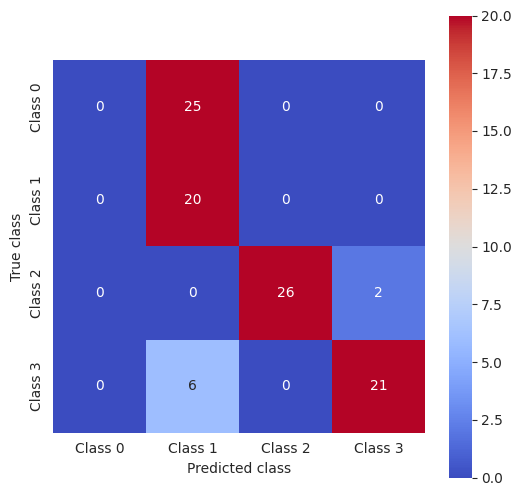

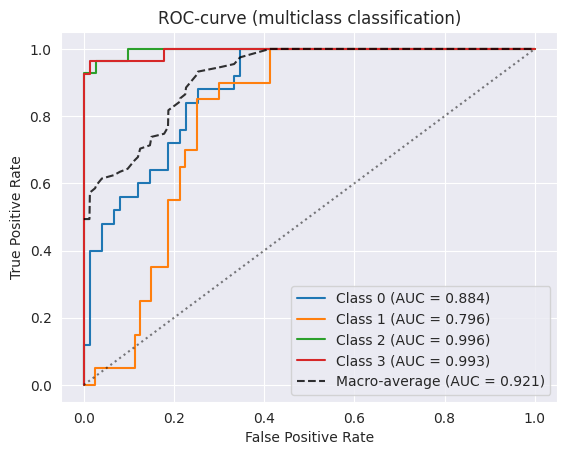

Macro-average ROC-AUC = 0.921


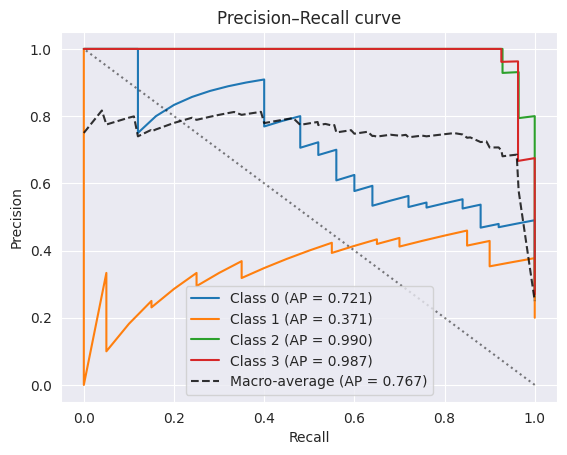

Macro-average AUC Precision–Recall = 0.767


In [10]:
pred = MNB_clf.predict(X_scaled_test)
get_model_score(y_test, pred)
plot_roc_auc(MNB_clf, X_scaled_test, y_test)
plot_pr_curve(MNB_clf, X_scaled_test, y_test)

In [11]:
# Overfitting
train_score = cross_val_score(MNB_clf, X_scaled_train, y_train, cv=5)
test_score = cross_val_score(MNB_clf, X_scaled_test, y_test, cv=5)
print(np.mean(train_score) - np.mean(test_score))

-0.023333333333333428


In [12]:
MNB_clf.predict_proba(X_scaled_test)

array([[0.25630216, 0.25797229, 0.21178706, 0.2739385 ],
       [0.26583354, 0.27106271, 0.1900701 , 0.27303365],
       [0.28405855, 0.30230906, 0.15254059, 0.2610918 ],
       [0.27372644, 0.28712293, 0.17565841, 0.26349222],
       [0.22164163, 0.21632123, 0.29771605, 0.2643211 ],
       [0.30799234, 0.34542551, 0.10275778, 0.24382437],
       [0.22430901, 0.21991493, 0.29147164, 0.26430441],
       [0.22204604, 0.21595599, 0.29567972, 0.26631824],
       [0.28251169, 0.30184574, 0.15695787, 0.25868469],
       [0.2832445 , 0.30585725, 0.15678152, 0.25411672],
       [0.27766495, 0.29714853, 0.16921856, 0.25596796],
       [0.25501997, 0.25556687, 0.2141313 , 0.27528186],
       [0.26521664, 0.27489461, 0.19498469, 0.26490406],
       [0.20405814, 0.19490412, 0.34158656, 0.25945118],
       [0.24468611, 0.24283571, 0.23909984, 0.27337834],
       [0.2855135 , 0.31046636, 0.15221954, 0.25180061],
       [0.28167953, 0.30340751, 0.16026412, 0.25464884],
       [0.26849925, 0.27544725,

## Dataset b

In [13]:
np.random.seed(0)
X = np.random.randn(300, 2)
Y = np.logical_xor(X[:,0] > 0, X[:,1] > 0)

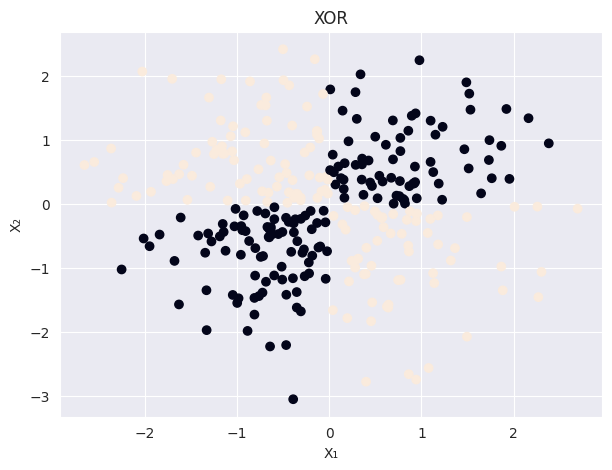

In [14]:
show_scatter(X, Y, title="XOR")

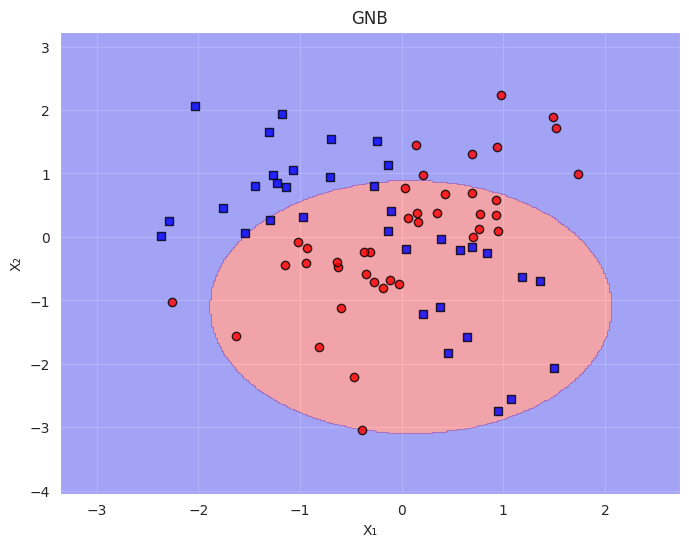

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.25, random_state=42, stratify=Y
)

GNB_clf = GaussianNB()
GNB_clf.fit(X_train, y_train)
plot_decision_regions(X_test, y_test, GNB_clf, model_name="GNB")

              precision    recall  f1-score   support

     Class 0       0.61      0.75      0.67        40
     Class 1       0.62      0.46      0.52        35

    accuracy                           0.61        75
   macro avg       0.61      0.60      0.60        75
weighted avg       0.61      0.61      0.60        75



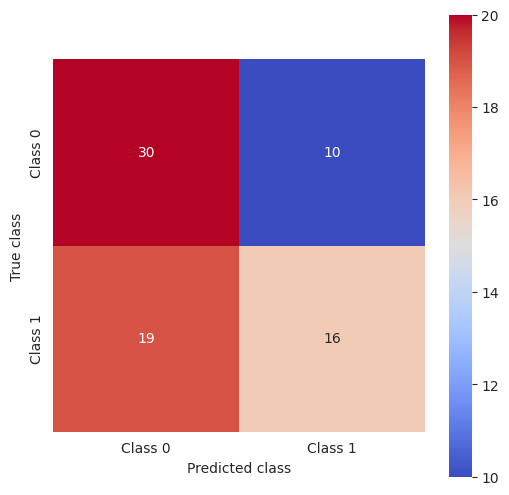

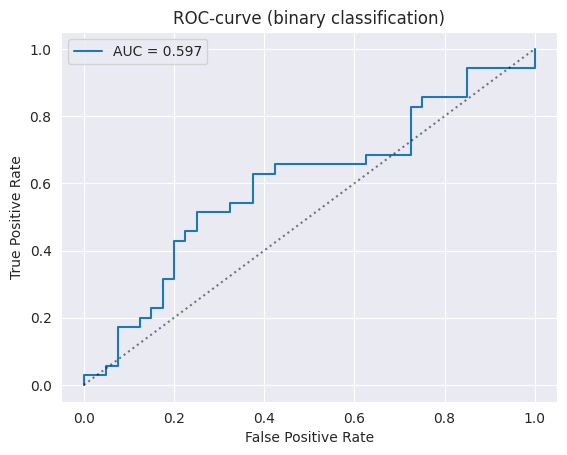

ROC–AUC = 0.597


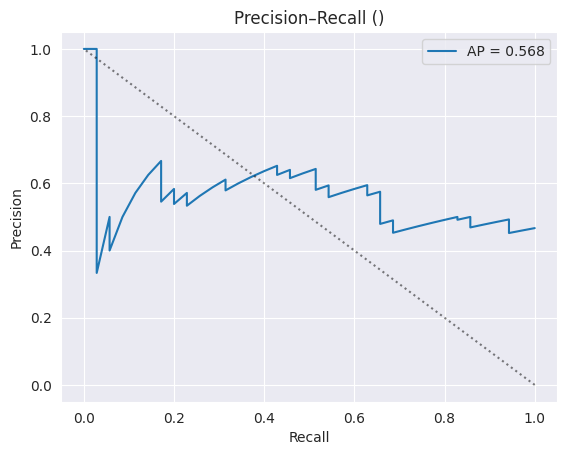

Average Precision (AUC PR) = 0.568


In [16]:
pred = GNB_clf.predict(X_test)
get_model_score(y_test, pred)
plot_roc_auc(GNB_clf, X_test, y_test)
plot_pr_curve(GNB_clf, X_test, y_test)

In [17]:
# Overfitting
train_score = cross_val_score(GNB_clf, X_train, y_train, cv=5)
test_score = cross_val_score(GNB_clf, X_test, y_test, cv=5)
print(np.mean(train_score) - np.mean(test_score))

-0.07555555555555549


In [18]:
GNB_clf.predict_proba(X_test)

array([[0.60422477, 0.39577523],
       [0.53712552, 0.46287448],
       [0.55437026, 0.44562974],
       [0.5477822 , 0.4522178 ],
       [0.57444092, 0.42555908],
       [0.43987366, 0.56012634],
       [0.57198381, 0.42801619],
       [0.50977123, 0.49022877],
       [0.57307134, 0.42692866],
       [0.59265269, 0.40734731],
       [0.52190118, 0.47809882],
       [0.40227315, 0.59772685],
       [0.40279624, 0.59720376],
       [0.59408154, 0.40591846],
       [0.31926375, 0.68073625],
       [0.44405957, 0.55594043],
       [0.58918115, 0.41081885],
       [0.55558577, 0.44441423],
       [0.41381628, 0.58618372],
       [0.58235394, 0.41764606],
       [0.44392045, 0.55607955],
       [0.5670557 , 0.4329443 ],
       [0.54873252, 0.45126748],
       [0.41639965, 0.58360035],
       [0.47622242, 0.52377758],
       [0.57902734, 0.42097266],
       [0.54594724, 0.45405276],
       [0.56486935, 0.43513065],
       [0.523646  , 0.476354  ],
       [0.49729406, 0.50270594],
       [0.

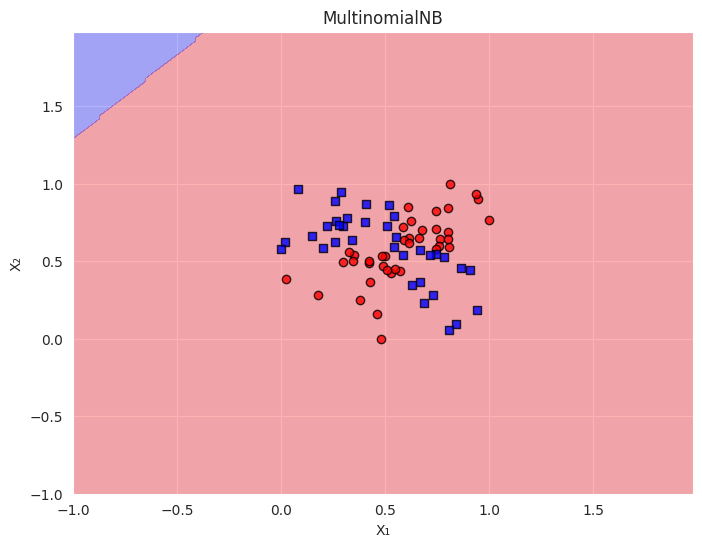

In [19]:
scaler = MinMaxScaler()

X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test = scaler.fit_transform(X_test)

MNB_clf = MultinomialNB()
MNB_clf.fit(X_scaled_train, y_train)

plot_decision_regions(X_scaled_test, y_test, MNB_clf, model_name="MultinomialNB")

              precision    recall  f1-score   support

     Class 0       0.53      1.00      0.70        40
     Class 1       0.00      0.00      0.00        35

    accuracy                           0.53        75
   macro avg       0.27      0.50      0.35        75
weighted avg       0.28      0.53      0.37        75



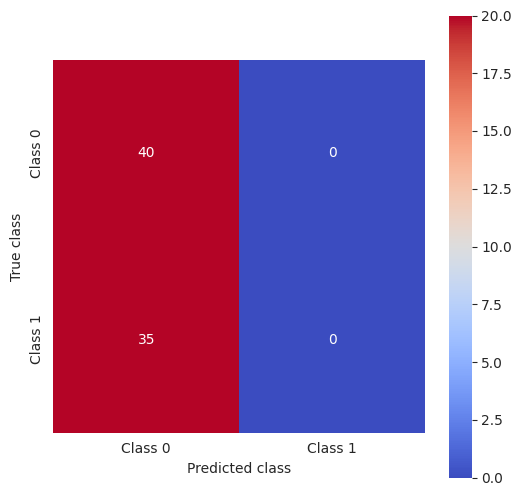

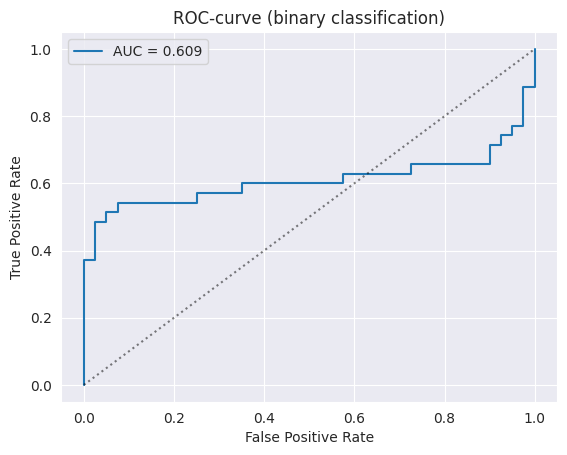

ROC–AUC = 0.609


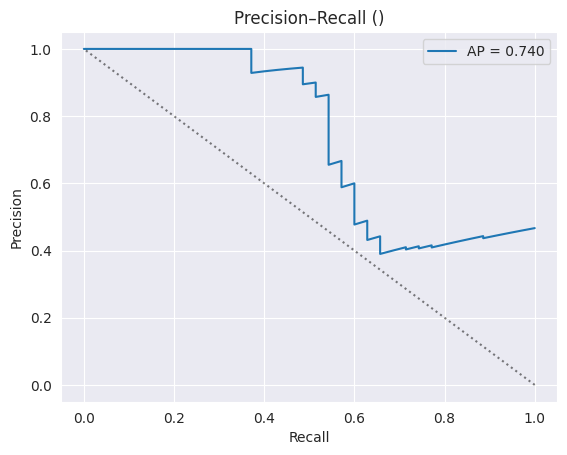

Average Precision (AUC PR) = 0.740


In [20]:
pred = MNB_clf.predict(X_scaled_test)
get_model_score(y_test, pred)
plot_roc_auc(MNB_clf, X_scaled_test, y_test)
plot_pr_curve(MNB_clf, X_scaled_test, y_test)

In [21]:
# Overfitting
train_score = cross_val_score(MNB_clf, X_scaled_train, y_train, cv=5)
test_score = cross_val_score(MNB_clf, X_scaled_test, y_test, cv=5)
print(np.mean(train_score) - np.mean(test_score))

-0.008888888888888946
